# INTRODUCTION

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">

This Exploratory Data Analysis (EDA) project analyzes a comprehensive US Real Estate dataset scraped from Realtor.com, containing over 2.2 million listing records across 10 key features. The primary focus is to examine the economic and physical factors driving real estate listing prices across different US states, cities, and zip codes. By applying data auditing, cleaning, and descriptive visualization techniques, this study aims to resolve data quality challenges like heavy skewness and missing values, while unearthing key market patterns to inform future predictive modeling and real estate insights.


</div>

# OBJECTIVES:

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">

<ul>
<li>Data Preprocessing: Clean the dataset by handling missing values, removing duplicates, filtering extreme outliers, and reformatting date/categorical fields.

<li>Univariate Analysis: Evaluate the overall distribution, skewness, and central tendencies of key numerical features such as price, house_size, and acre_lot.

<li>Geographical Insights: Analyze price variations and price-per-square-foot trends across different states, cities, and zip codes to identify high-value versus affordable markets.

<li>Correlation & Relationship Mapping: Determine the strength of relationships between physical property features (bedrooms, bathrooms, living area) and final listing prices.

<li>Temporal Trend Analysis: Explore historical market behavior using prev_sold_date to observe sales activity patterns over time.

<li>Feature Engineering: Create derived metrics like price_per_sqft and total_rooms to prepare a clean, structured baseline for future machine learning models.

</div>

<div
>

# 1. Getting Ready with Datasets


In [1]:
import numpy as np
import pandas as pd
import polars as pl

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
data = pd.read_parquet('/home/kartika/Datasets/brazilianolist.csv', engine='pyarrow')

for col in data.select_dtypes(include = ['object']).columns :
    data[col] = data[col].astype('category')

for col in data.select_dtypes(include = ['int', 'float']).columns :
    data[col] = pd.to_numeric(data[col], downcast = 'integer' if 'int' in str(data[col].dtype) else 'float')



print(f"Memory Usage: {data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


Memory Usage: 108.87 MB


<div>

<div>

# 2. Cleaning and Wrangling

In [3]:
data.head(5)


,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN


In [4]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 12 columns):
 #   Column          Dtype   
---  ------          -----   
 0   brokered_by     float32 
 1   status          category
 2   price           float64 
 3   bed             float32 
 4   bath            float32 
 5   acre_lot        float64 
 6   street          float32 
 7   city            category
 8   state           category
 9   zip_code        float32 
 10  house_size      float64 
 11  prev_sold_date  category
dtypes: category(4), float32(5), float64(3)
memory usage: 107.4 MB


In [5]:
data.isnull().sum()

brokered_by         4533
status                 0
price               1541
bed               481317
bath              511771
acre_lot          325589
street             10866
city                1407
state                  8
zip_code             299
house_size        568484
prev_sold_date    734297
dtype: int64

In [ ]:
data.duplicated().sum()

<div>

In [6]:
data.drop(columns = ['brokered_by'], inplace = True)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Removed 'brokered_by', irrelevant field for both EDA and modeling.

In [7]:
data['price'] = data['price'].fillna(
    data.groupby('city', observed = True)['price'].transform('median')
)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify"><1% values are missing, imputed them with median price, grouped by city.

<div>

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
Around 22% values are missing in bed field and 23% values are missing in bath field. Since they correlate with house_size, so will be handled collectively during feature engineering.

<div>




<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Around 15% values are missing in acre_lot. Since this is the main factor to determine house_size and other entities on land, will be handled during feature engineering.

<div>

In [8]:
data['city'] = data['city'].dropna()

In [9]:
data['state'] = data['city'].dropna()

In [10]:
data['zip_code'] = data['zip_code'].dropna()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
Since, <1% values are missing, dropped them.

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Around 25% values are missing in house_size, since tis features corelates with bed and bath , will be handled during feature engineering.

<div>

<div>

# 3. Exploratory Data Analysis

## 3.1 Valuation and History (Price, TV)



In [ ]:
data['price'].describe()

count    2.226361e+06
mean     5.240370e+05
std      2.138176e+06
min      0.000000e+00
25%      1.650000e+05
50%      3.250000e+05
75%      5.500000e+05
max      2.147484e+09
Name: price, dtype: float64

In [ ]:
data['price'].skew()

np.float64(546.4801067387821)

In [ ]:
Q1 = data['price'].quantile(0.25)
Q3 = data['price'].quantile(0.75)

IQR = Q3-Q1
lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR

outliers = data[(data['price'] < lower_bound) | (data['price'] > upper_bound)]

print(f"Percentage of Outliers : {len(outliers)/len(data) * 100}")

Percentage of Outliers : 7.707572195607043


In [ ]:
bins = [-np.inf, 0, 200000, 450000, 800000, 2000000, np.inf]
labels = [
    "Invalid/Free",
    "Budget (<200k)",
    "Mid-Range (200k-450k)",
    "Upper Mid (450k-800k)",
    "Luxury (800k-2M)",
    "Ultra Luxury (>2M)",
]


data["price_category"] = pd.cut(data["price"], bins=bins, labels=labels)

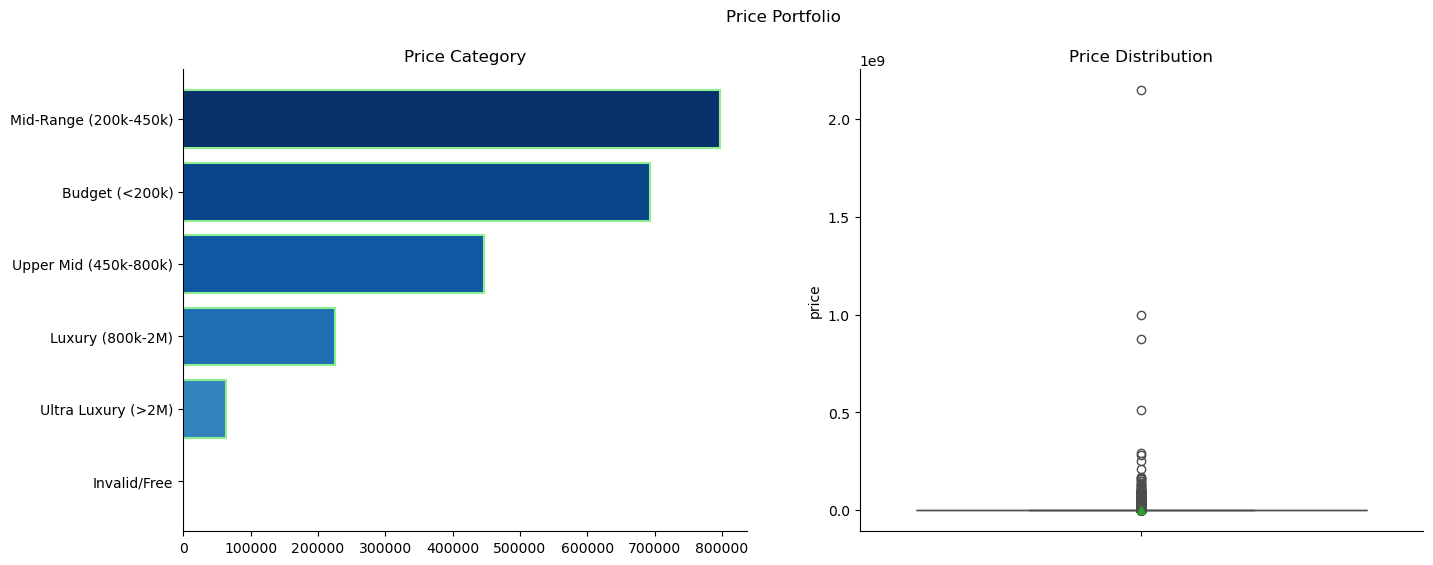

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (16,6))

ax[0].barh(
    y = data['price_category'].value_counts().index,
    width = data['price_category'].value_counts().values,
    color = plt.cm.Blues(np.linspace(1, 0.6, 6)),
    linewidth = 1.5,
    edgecolor = 'lightgreen'
)
ax[0].set_title('Price Category')
ax[0].invert_yaxis()

sns.boxplot(
    data = data,
    y = 'price',
    color = 'blue',
    showmeans = True,
    ax = ax[1]
)
ax[1].set_title('Price Distribution')


plt.suptitle('Price Portfolio')
sns.despine()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Most of the houses have mid-range to budget price. The distribution is extremely positively skewed, with most the houses having price arond half million, while few houses priced extremely high.

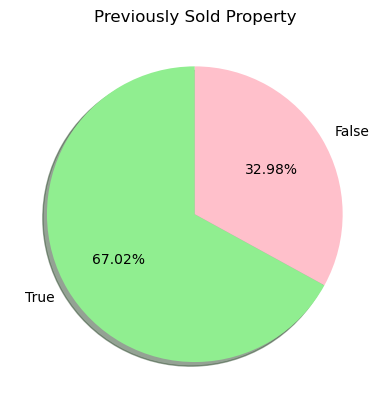

In [ ]:
plt.pie(
    data['has_prev_sale'].value_counts().values,
    labels = data['has_prev_sale'].value_counts().index,
    colors = ['lightgreen', 'pink'],
    autopct = '%1.2f%%',
    shadow = True,
    startangle = 90
)

plt.title('Previously Sold Property')
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Around 67% of the property has been previously sold. While, nearly 33% of the property never sold previously.

<div>

## 3.2 Property Profile vs Price

In [ ]:
data['status'].value_counts()

status
for_sale          1389306
sold               812009
ready_to_build      25067
Name: count, dtype: int64

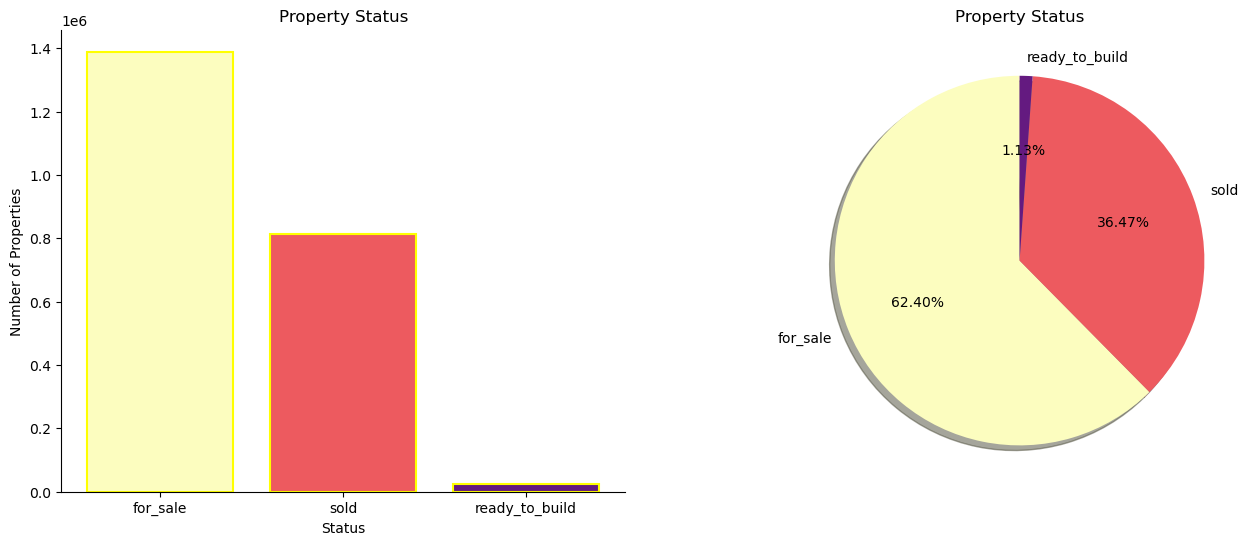

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (16, 6))

ax[0].bar(
    x = data['status'].value_counts().index,
    height = data['status'].value_counts().values,
    color = plt.cm.magma(np.linspace(1, 0.3, 3)),
    linewidth = 1.5,
    edgecolor = 'yellow'


)
ax[0].set_title('Property Status')
ax[0].set_xlabel('Status')
ax[0].set_ylabel('Number of Properties')


ax[1].pie(
    data['status'].value_counts().values,
    labels = data['status'].value_counts().index,
    autopct = '%1.2f%%',
    shadow = True,
    startangle = 90,
    colors = plt.cm.magma(np.linspace(1, 0.3, 3))
)
ax[1].set_title('Property Status')

sns.despine()
plt.show()


<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">62% of the property have already built house, which are ready for sale. 36% of the property houses have already sold and rest less than 2% of the property are ready for house to be built.

<div>

In [ ]:
data['bed'].describe()

count    2.226382e+06
mean     3.217800e+00
std      1.389755e+00
min      1.000000e+00
25%      3.000000e+00
50%      3.000000e+00
75%      4.000000e+00
max      4.730000e+02
Name: bed, dtype: float64

In [ ]:
data['bed'].skew()

np.float32(62.679264)

In [ ]:
data['bed'].corr(data['price'])

np.float64(0.10950855070543701)

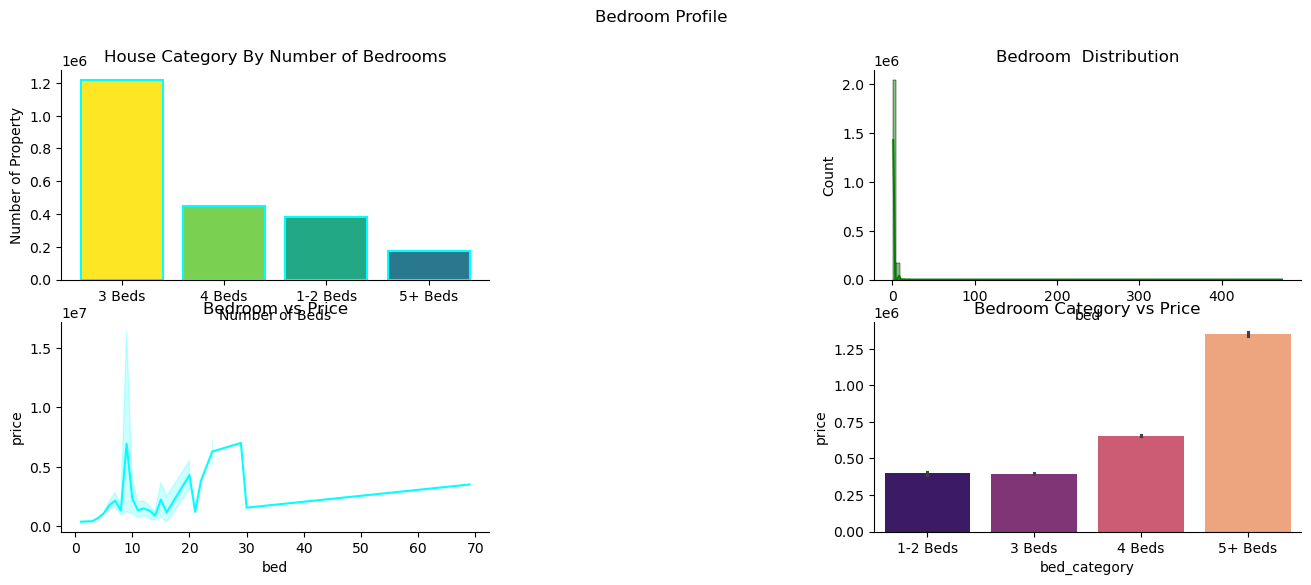

In [ ]:
# fig, ax = plt.subplots(2, 2, figsize = (16,6))

# bins = [0, 2, 3, 4, np.inf]
# labels = ['1-2 Beds', '3 Beds', '4 Beds', '5+ Beds']

# data['bed_category'] = pd.cut(data['bed'], bins=bins, labels=labels)

# # Plot1 : Bedroom Category Distribution
# ax[0][0].bar(
#     x = data['bed_category'].value_counts().index,
#     height= data['bed_category'].value_counts().values,
#     color = plt.cm.viridis(np.linspace(1, 0.4, 4)),
#     linewidth = 1.5,
#     edgecolor = 'cyan'
# )
# ax[0][0].set_title('House Category By Number of Bedrooms')
# ax[0][0].set_xlabel('Number of Beds')
# ax[0][0].set_ylabel('Number of Property')


# # Plot2 : Bedroom Distribution
# sns.histplot(
#     data = data,
#     x = 'bed',
#     bins = 120,
#     color = 'green',
#     kde = True,
#     ax = ax[0][1]
# )
# ax[0][1].set_title('Bedroom  Distribution')



# #Plot3 : Bedroom vs Price
# sns.lineplot(
#     data = data.sample(30000),
#     x = 'bed',
#     y = 'price',
#     color = 'cyan',
#     markerfacecolor = 'green',
#     ax = ax[1][0],
# )
# ax[1][0].set_title('Bedroom vs Price')


# #Plot4 : Bedroom Category vs Price
# sns.barplot(
#     data = data,
#     x = 'bed_category',
#     y = 'price',
#     hue = 'bed_category',
#     palette = 'magma',
#     ax = ax[1][1]
# )
# ax[1][1].set_title('Bedroom Category vs Price')





# plt.suptitle('Bedroom Profile')
# plt.subplots_adjust(wspace = 0.9)
# sns.despine()
# plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">There is very weak(negligible) correlation between the number of bedrooms and price of the property. The data the highly skewed so the relation is distorted. Category wise, houses with more than 3 beds have very high price.

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The bedroom distribution among house property is extremely positively skewed, majority of housese have 1-4 bedrooms, while rest have extremely large number of bedrooms.

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
Description:
<ul>
<li>1–2 Beds : Small homes, apartments, starter properties
<li>3 Beds : Standard average home (covers the 25%–50% median bulk)
<li>4 Beds : Larger family homes
<li>5+ : Beds Luxury, multi-family, or extreme data outliers
</ul>
</div>


<div>

In [ ]:
data['bath'].describe()

count    2.226382e+06
mean     2.400124e+00
std      1.474355e+00
min      1.000000e+00
25%      2.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      8.300000e+02
Name: bath, dtype: float64

In [ ]:
data['bath'].skew()

np.float32(164.93558)

In [ ]:
data['price'].corr(data['bath'])

np.float64(0.1704546243366539)

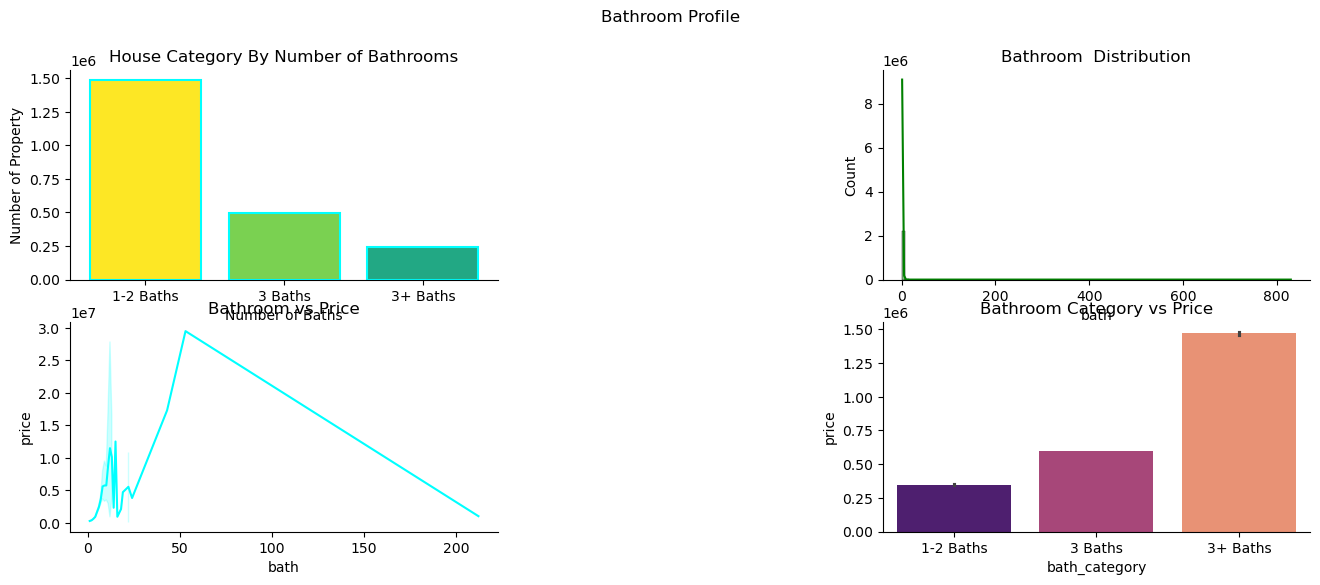

In [ ]:
# bins = [0, 2, 3, np.inf]
# labels = ['1-2 Baths', '3 Baths','3+ Baths']

# data['bath_category'] = pd.cut(data['bath'], bins=bins, labels=labels)




# fig, ax = plt.subplots(2,2, figsize = (16,6))

# # Plot1 : Bathroom Category Distribution
# ax[0][0].bar(
#     x = data['bath_category'].value_counts().index,
#     height= data['bath_category'].value_counts().values,
#     color = plt.cm.viridis(np.linspace(1, 0.4, 4)),
#     linewidth = 1.5,
#     edgecolor = 'cyan'
# )
# ax[0][0].set_title('House Category By Number of Bathrooms')
# ax[0][0].set_xlabel('Number of Baths')
# ax[0][0].set_ylabel('Number of Property')


# # Plot2 : Bathroom Distribution
# sns.histplot(
#     data = data,
#     x = 'bath',
#     bins = 120,
#     color = 'green',
#     kde = True,
#     ax = ax[0][1]
# )
# ax[0][1].set_title('Bathroom  Distribution')



# #Plot3 : Bathroom vs Price
# sns.lineplot(
#     data = data.sample(30000),
#     x = 'bath',
#     y = 'price',
#     color = 'cyan',
#     markerfacecolor = 'green',
#     ax = ax[1][0],
# )
# ax[1][0].set_title('Bathroom vs Price')


# #Plot4 : Bathroom Category vs Price
# sns.barplot(
#     data = data,
#     x = 'bath_category',
#     y = 'price',
#     hue = 'bath_category',
#     palette = 'magma',
#     ax = ax[1][1]
# )
# ax[1][1].set_title('Bathroom Category vs Price')





# plt.suptitle('Bathroom Profile')
# plt.subplots_adjust(wspace = 0.9)
# sns.despine()
# plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
Description:
<ul>
<li> 1–2 Baths : Small homes, starter properties(covers the 25%-50% median bulk)
<li> 3 Baths : Larger family homes
<li> 3+ Baths : Multi-family, Apartments, or extreme data outliers
</ul>
</div>


<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The bathroom distribution among house property is extremely positively skewed, majority of housese have 1-2 bedrooms, while rest have large number of bathrooms.

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">There is very weak(negligible) correlation between the number of bathrooms and price of the property. The data the highly skewed so the relation is distorted. Category wise, houses with more than 3 bathrooms have very high price.

<div>

<div>

In [ ]:
data['acre_lot'].describe() 

count    2.226376e+06
mean     1.306959e+01
std      7.049120e+02
min      0.000000e+00
25%      1.500000e-01
50%      2.500000e-01
75%      7.500000e-01
max      1.000000e+05
Name: acre_lot, dtype: float64

In [ ]:
data['house_size'].describe()

count    2.226382e+06
mean     2.451054e+03
std      6.973954e+05
min      4.000000e+00
25%      1.383500e+03
50%      1.647000e+03
75%      2.206000e+03
max      1.040400e+09
Name: house_size, dtype: float64

In [ ]:
print(f"Skewness of House Size : {data['house_size'].skew()}")
print(f"Skewness of Acre lot: {data['acre_lot'].skew()}")
print(f"Correlation of House Size and Price: {data['house_size'].corr(data['price'])}")
print(f"Correlation of Acre Lot and Price: {data['acre_lot'].corr(data['price'])}")

Skewness of House Size : 1491.294813493341
Skewness of Acre lot: 114.99914055428152
Correlation of House Size and Price: 0.00027541960679741776
Correlation of Acre Lot and Price: 0.014925752209494773


In [ ]:
def out_per(col, data):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    per = len(data[(data[col] < lower_bound) | (data[col] > upper_bound)]) / len(data) * 100
    print(f"Percentage of outliers in {col}: {per:.2f}%")

In [ ]:
out_per('house_size', data)

Percentage of outliers in house_size: 6.71%


In [ ]:
out_per('acre_lot', data)

Percentage of outliers in acre_lot: 15.73%


In [ ]:
# fig, ax = plt.subplots(2,2, figsize = (20,8))

# sns.histplot(
#     data = data,
#     x = 'acre_lot',
#     bins = 90,
#     color = 'blue',
#     kde = True,
#     ax = ax[0][0]
# )
# ax[0][0].set_title('Land Size Distribution')

# sns.histplot(
#     data = data, 
#     x = 'house_size',
#     color = 'cyan',
#     kde = True,
#     bins = 90,
#     ax = ax[0][1]
    
# )
# ax[0][1].set_title('House Size Distribution (sq_ft)')





# sns.lineplot(
#     data = data.sample(30000),
#     x = 'house_size',
#     y = 'price',
#     color = 'cyan',
#     markerfacecolor = 'green',
#     ax = ax[1][0],
# )
# ax[1][0].set_title('House size vs Price')



# sns.lineplot(
#     data = data.sample(30000),
#     x = 'acre_lot',
#     y = 'price',
#     color = 'cyan',
#     markerfacecolor = 'green',
#     ax = ax[1][1],
# )
# ax[1][1].set_title('Acre Lot vs Price')

# plt.suptitle('Property Size Profile')
# sns.despine()
# plt.subplots_adjust(wspace = 0.9)
# plt.tight_layout()
# plt.show()





<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The land size distribution is extremely positivley skewed. Majority of land size is less than or equal to 0.75 acres, while rest properties have extremely large land size.

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The hosue distribution is extremely positively skewed. Majority of house size is around 2200 sqft and many plot do not have houses build on them.

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">There is a extremely weak positive correlation between house size or acre plot with price of the property.

<div>

<div>

## 3.3 Location vs Price

In [ ]:
data['city'].value_counts()

city
Houston                      23862
Chicago                      18238
New York City                12634
Jacksonville                 11743
Philadelphia                 10449
                             ...  
4th Saint                        1
480th Saint                      1
30 31 Boardwalk Dr               1
3 Mi Southwest of Benteen        1
3 4 Highview Dr                  1
Name: count, Length: 20098, dtype: int64

In [ ]:
data['state'].value_counts()

state
Houston                      23862
Chicago                      18238
New York City                12634
Jacksonville                 11743
Philadelphia                 10449
                             ...  
4th Saint                        1
480th Saint                      1
30 31 Boardwalk Dr               1
3 Mi Southwest of Benteen        1
3 4 Highview Dr                  1
Name: count, Length: 20098, dtype: int64

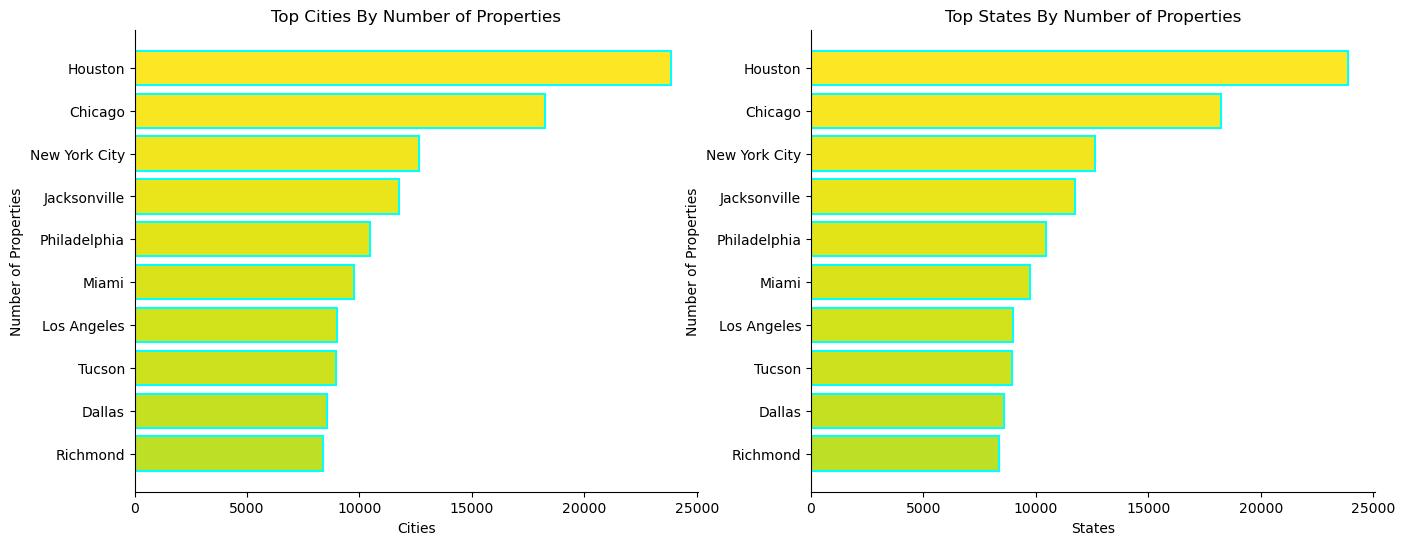

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (16, 6))

ax[0].barh(
    y = data['city'].value_counts().head(10).index,
    width = data['city'].value_counts().head(10).values,
    color = plt.cm.viridis(np.linspace(1, 0.9, 10 )),
    linewidth = 1.5,
    edgecolor = 'cyan'
)
ax[0].set_title('Top Cities By Number of Properties')
ax[0].set_ylabel('Number of Properties')
ax[0].set_xlabel('Cities')
ax[0].invert_yaxis()



ax[1].barh(
    y = data['state'].value_counts().head(10).index,
    width = data['state'].value_counts().head(10).values,
    color = plt.cm.viridis(np.linspace(1, 0.9, 10 )),
    linewidth = 1.5,
    edgecolor = 'cyan'
)
ax[1].set_title('Top States By Number of Properties')
ax[1].set_ylabel('Number of Properties')
ax[1].set_xlabel('States')
ax[1].invert_yaxis()




sns.despine()
plt.show()

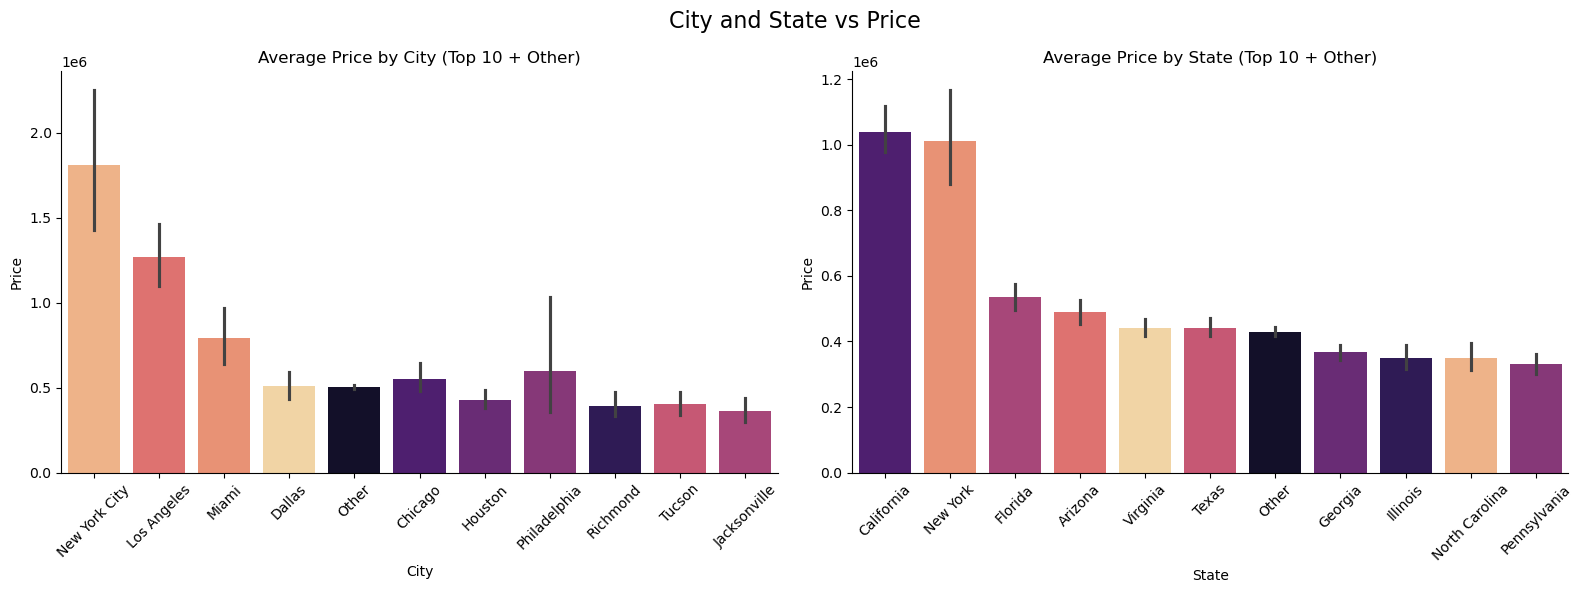

In [ ]:


fig, ax = plt.subplots(1, 2, figsize=(16, 6))


top_cities = data['city'].value_counts().nlargest(10).index

data['city_grouped'] = (
    data['city'].astype(str).where(data['city'].isin(top_cities), 'Other')
)

city_order = (
    data.groupby('city_grouped')['price']
    .mean()
    .sort_values(ascending=False)
    .index
)

sns.barplot(
    data=data.sample(min(30000, len(data))),
    x='city_grouped',
    y='price',
    hue='city_grouped',
    order=city_order,
    palette='magma',
    ax=ax[0],
    legend=False,
)
ax[0].set_title('Average Price by City (Top 10 + Other)')
ax[0].set_xlabel('City')
ax[0].set_ylabel('Price')
ax[0].tick_params(axis='x', rotation=45)


top_states = data['state'].value_counts().nlargest(10).index


data['state_grouped'] = (
    data['state'].astype(str).where(data['state'].isin(top_states), 'Other')
)


state_order = (
    data.groupby('state_grouped')['price']
    .mean()
    .sort_values(ascending=False)
    .index
)


sns.barplot(
    data=data.sample(min(30000, len(data))),
    x='state_grouped',
    y='price',
    hue='state_grouped',
    order=state_order,
    palette='magma',
    ax=ax[1],
    legend=False,
)
ax[1].set_title('Average Price by State (Top 10 + Other)')
ax[1].set_xlabel('State')
ax[1].set_ylabel('Price')
ax[1].tick_params(axis='x', rotation=45)


plt.suptitle('City and State vs Price', fontsize=16)
sns.despine()
plt.tight_layout()
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">Houston and Chicago are major city/state by number of properties.<br>
New York, Los Angeles and Miami are top three cities by highest average property pirce.<br>
California, New York and Florida are top three states by highest average property price.

<div>

<div>

# 5. Featuring Engineering


bins = list(range(0, 10000, 500)) + [np.inf]
data['sqft_bin'] = pd.cut(data['house_size'], bins=bins)


data['bed'] = data['bed'].fillna(
    data.groupby('sqft_bin', observed=True)['bed'].transform('median')
)

data['bath'] = data['bath'].fillna(
    data.groupby('sqft_bin', observed=True)['bath'].transform('median')
)

data['bed'] = data['bed'].fillna(data['bed'].median())
data['bath'] = data['bath'].fillna(data['bath'].median())

<!-- data['acre_lot'] = data['acre_lot'].fillna(
    data.groupby('city', observed=True)['acre_lot'].transform('median')
)


if 'state' in data.columns:
    data['acre_lot'] = data['acre_lot'].fillna(
        data.groupby('state', observed=True)['acre_lot'].transform('median')
    ) -->

<!-- import numpy as np
import pandas as pd

# 1. Group by highly correlated local features
# Zip code + bed + bath gives the tightest spatial & structural match
group_cols = ['zip_code', 'bed', 'bath']

# Calculate group medians
data['house_size_imputed'] = data.groupby(group_cols)['house_size'].transform(
    lambda x: x.fillna(x.median())
)

# 2. Fallback Hierarchical Imputation for small groups/rare combinations:
# Fallback 1: City + Bed + Bath
data['house_size_imputed'] = data['house_size_imputed'].fillna(
    data.groupby(['city', 'bed', 'bath'])['house_size'].transform('median')
)

# Fallback 2: State + Bed + Bath
data['house_size_imputed'] = data['house_size_imputed'].fillna(
    data.groupby(['state', 'bed', 'bath'])['house_size'].transform('median')
)

# Fallback 3: Bed + Bath overall
data['house_size_imputed'] = data['house_size_imputed'].fillna(
    data.groupby(['bed', 'bath'])['house_size'].transform('median')
) -->